# Part II. The Housing Prices

1. Join the House Prices - Advanced Regression Techniques competition on Kaggle. Download the training and test data.

Done

2. Give 3 examples of continuous and categorical features in the dataset; choose one feature of each
type and plot the histogram to illustrate the distribution.

Continuous Variables:
- **LotArea**: Lot size in square feet
- **TotalBsmtSF**: Total square feet of basement area
- **1stFlrSF**: First Floor square feet

Categorical Variables:
- **Foundation**: Type of foundation
- **RoofMatl**: Roof material
- **Heating**: Type of heating

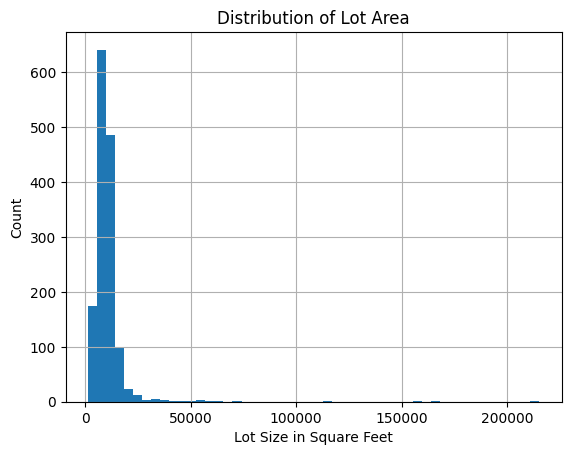

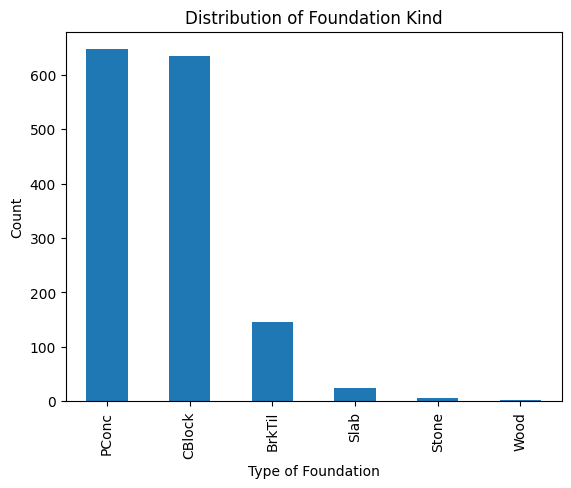

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

test_df = pd.read_csv("test.csv")
train_df = pd.read_csv("train.csv")

# Plot of LotArea (continuous plot)
train_df["LotArea"].hist(bins=50)
plt.xlabel("Lot Size in Square Feet")
plt.ylabel("Count")
plt.title("Distribution of Lot Area")
plt.show()

# Plot of Heating (categorical plot)
train_df["Foundation"].value_counts().plot(kind="bar")
plt.xlabel("Type of Foundation")
plt.ylabel("Count")
plt.title("Distribution of Foundation Kind")
plt.show()

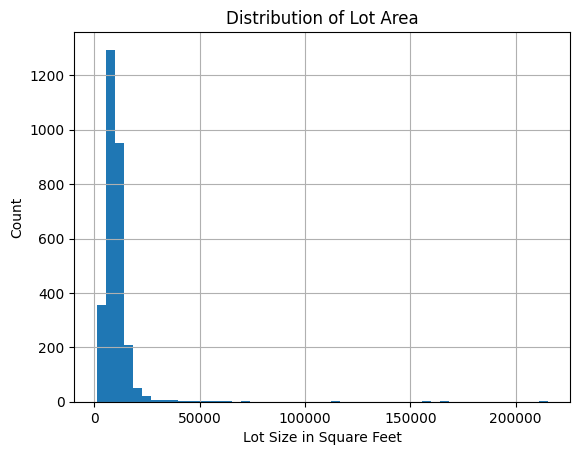

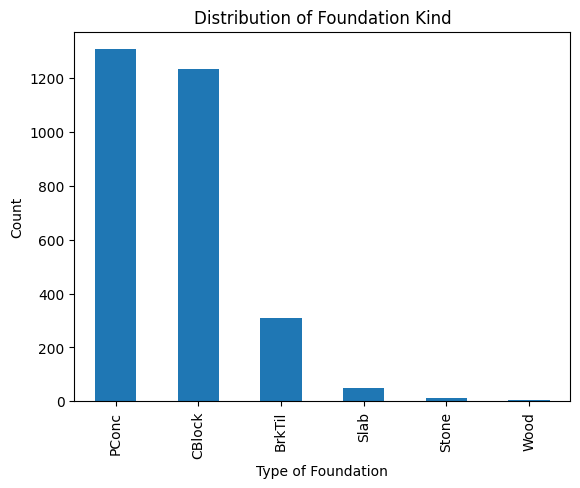

In [2]:
merged_df = pd.concat([test_df, train_df], axis=0, ignore_index=True)

# Plot of LotArea (continuous plot)
merged_df["LotArea"].hist(bins=50)
plt.xlabel("Lot Size in Square Feet")
plt.ylabel("Count")
plt.title("Distribution of Lot Area")
plt.show()

# Plot of Heating (categorical plot)
merged_df["Foundation"].value_counts().plot(kind="bar")
plt.xlabel("Type of Foundation")
plt.ylabel("Count")
plt.title("Distribution of Foundation Kind")
plt.show()

3. Pre-process your data, explain your pre-processing steps, and the reasons why you need them. \
(Hint: data pre-processing steps can include but are not restricted to: dealing with missing values,
normalizing numerical values, dealing with categorical values etc.)

In [3]:
import pandas as pd

test_df = pd.read_csv("test.csv")
train_df = pd.read_csv("train.csv")

# print(train_df.head())

# Dropping the two known outliers that are huge living areas that sold for very little (they're partial sales)
print(train_df[train_df["GrLivArea"] > 4000][["Id", "GrLivArea", "SalePrice", "SaleCondition"]])
train_df = train_df[~((train_df["GrLivArea"] > 4000) & (train_df["SalePrice"] < 300000))].reset_index(drop=True)

y_train = train_df["SalePrice"]
test_ids = test_df["Id"]
n_train = len(train_df)

train_features = train_df.drop(columns=["SalePrice", "Id"])
test_features = test_df.drop(columns=["Id"])

combined_df = pd.concat([train_features, test_features], axis=0, ignore_index=True)
combined_df.info()


        Id  GrLivArea  SalePrice SaleCondition
523    524       4676     184750       Partial
691    692       4316     755000        Normal
1182  1183       4476     745000       Abnorml
1298  1299       5642     160000       Partial
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2917 non-null   int64  
 1   MSZoning       2913 non-null   object 
 2   LotFrontage    2431 non-null   float64
 3   LotArea        2917 non-null   int64  
 4   Street         2917 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2917 non-null   object 
 7   LandContour    2917 non-null   object 
 8   Utilities      2915 non-null   object 
 9   LotConfig      2917 non-null   object 
 10  LandSlope      2917 non-null   object 
 11  Neighborhood   2917 non-null   object 
 12  Condition1     2917 non-null   object

Looking at the data_description.txt file, we see that the following columns have "NA" meaning that it doesn't have that feature (for example "NA" for the "Alley" column means "No alley access", but pandas treats that as "NaN"):
- Alley
- MasVnrType
- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2
- FireplaceQu
- GarageType
- GarageFinish
- GarageQual
- GarageCond
- PoolQC
- Fence
- MiscFeature

In [4]:
none_cols = ["Alley",
             "MasVnrType", 
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "PoolQC",
             "Fence",
             "MiscFeature"]

# print(combined_df.isna().sum()[combined_df.isna().sum() > 0].sort_values(ascending=False))

combined_df[none_cols] = combined_df[none_cols].fillna("None")

print(combined_df[none_cols].isna().sum())


Alley           0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64


Now we look at the corresponding numeric columns for some of the columns above, in which they are blank because the house doesn't have it (so like the column "GarageCars" being zero when there isn't a garage). We want to make sure these are filled with zero, and we'll just set the GarageYrBlt to the year the house was build ("YearBuilt") so that it doesn't have a year of "0". So from above's columns and looking at the data_description.txt file, we have:
- MasVnrArea
- BsmtFinSF1
- BsmtFinSF2
- BsmtUnfSF
- TotalBsmtSF
- BsmtFullBath
- BsmtHalfBath
- GarageYrBlt
- GarageCars
- GarageArea

In [5]:
zero_cols = ["MasVnrArea",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
             "GarageCars", "GarageArea"]

print(combined_df[zero_cols + ["GarageYrBlt"]].isna().sum())

MasVnrArea       23
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
GarageCars        1
GarageArea        1
GarageYrBlt     159
dtype: int64


In [6]:
combined_df[zero_cols] = combined_df[zero_cols].fillna(0)
combined_df["GarageYrBlt"] = combined_df["GarageYrBlt"].fillna(combined_df["YearBuilt"])
combined_df.loc[combined_df["GarageYrBlt"] > 2010, "GarageYrBlt"] = combined_df["YearBuilt"]

print(combined_df[zero_cols + ["GarageYrBlt"]].isna().sum())

MasVnrArea      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
GarageCars      0
GarageArea      0
GarageYrBlt     0
dtype: int64


In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2917 non-null   int64  
 1   MSZoning       2913 non-null   object 
 2   LotFrontage    2431 non-null   float64
 3   LotArea        2917 non-null   int64  
 4   Street         2917 non-null   object 
 5   Alley          2917 non-null   object 
 6   LotShape       2917 non-null   object 
 7   LandContour    2917 non-null   object 
 8   Utilities      2915 non-null   object 
 9   LotConfig      2917 non-null   object 
 10  LandSlope      2917 non-null   object 
 11  Neighborhood   2917 non-null   object 
 12  Condition1     2917 non-null   object 
 13  Condition2     2917 non-null   object 
 14  BldgType       2917 non-null   object 
 15  HouseStyle     2917 non-null   object 
 16  OverallQual    2917 non-null   int64  
 17  OverallCond    2917 non-null   int64  
 18  YearBuil

So looking at above, we still need to fill "MSZoning" (needs 4), "LotFrontage" (needs 486), "Utilities" (needs 2), "Exterior1st" (needs 1), "Exterior2nd" (needs 1), "Electrical" (needs 1), "KitchenQual" (needs 1), "Functional" (needs 2), and "Saletype" (needs 1).

So for all of those columns except for LotFrontage (which is numeric), we'll fill them with the mode of that column

In [8]:
mode_cols = ["MSZoning", "Utilities", "Exterior1st", "Exterior2nd", "Electrical", "KitchenQual", "Functional", "SaleType"]

for col in mode_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])

print(combined_df[mode_cols].isna().sum())

MSZoning       0
Utilities      0
Exterior1st    0
Exterior2nd    0
Electrical     0
KitchenQual    0
Functional     0
SaleType       0
dtype: int64


Then for "LotFrontage", there are 486 that are missing, so what I am doing here is filling the blanks with the median frontage of houses in the same neighborhood, because this is a better guess than just using the median frontage of all the houses.

In [9]:
combined_df["LotFrontage"] = combined_df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
print(combined_df["LotFrontage"].isna().sum())

0


In [10]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2917 non-null   int64  
 1   MSZoning       2917 non-null   object 
 2   LotFrontage    2917 non-null   float64
 3   LotArea        2917 non-null   int64  
 4   Street         2917 non-null   object 
 5   Alley          2917 non-null   object 
 6   LotShape       2917 non-null   object 
 7   LandContour    2917 non-null   object 
 8   Utilities      2917 non-null   object 
 9   LotConfig      2917 non-null   object 
 10  LandSlope      2917 non-null   object 
 11  Neighborhood   2917 non-null   object 
 12  Condition1     2917 non-null   object 
 13  Condition2     2917 non-null   object 
 14  BldgType       2917 non-null   object 
 15  HouseStyle     2917 non-null   object 
 16  OverallQual    2917 non-null   int64  
 17  OverallCond    2917 non-null   int64  
 18  YearBuil

Now looking at the info, we have to fix columns that are stored as the wrong type. Looking at the data_description.txt as well, we see that "MSSubClass" is a label, but that data has it as an integer value rather than an object, and the same for "MoSold", which should be an object (relating to the month number) and not an integer.

In [11]:
combined_df["MSSubClass"] = combined_df["MSSubClass"].astype(str)
combined_df["MoSold"] = combined_df["MoSold"].astype(str)

print(combined_df[["MSSubClass", "MoSold"]].dtypes)

MSSubClass    object
MoSold        object
dtype: object


Next, there are columns that are categorical and mapped to some quality/condition, so we can map them to ordered rankings. Looking again at data_description.txt, we have the following that use the same scale (Ex, Gd, TA, Fa, Po, [some have NA too]):
- ExterQual
- ExterCond
- BsmtQual
- BsmtCond
- HeatingQC
- KitchenQual
- FireplaceQu
- GarageQual
- GarageCond
- PoolQC

In [12]:
quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}

quality_cols = ["ExterQual", "ExterCond",
                "BsmtQual", "BsmtCond", 
                "HeatingQC",
                "KitchenQual",
                "FireplaceQu",
                "GarageQual", "GarageCond",
                "PoolQC"]
for col in quality_cols:
    combined_df[col] = combined_df[col].map(quality_map)

print(combined_df[quality_cols].isna().sum())

ExterQual      0
ExterCond      0
BsmtQual       0
BsmtCond       0
HeatingQC      0
KitchenQual    0
FireplaceQu    0
GarageQual     0
GarageCond     0
PoolQC         0
dtype: int64


Then for the other categorical columns that use there own scales, we just have them use their own dictionary.

In [13]:
combined_df["BsmtExposure"] = combined_df["BsmtExposure"].map({"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0})

fin_map = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0}
combined_df["BsmtFinType1"] = combined_df["BsmtFinType1"].map(fin_map)
combined_df["BsmtFinType2"] = combined_df["BsmtFinType2"].map(fin_map)

combined_df["GarageFinish"] = combined_df["GarageFinish"].map({"Fin": 3, "RFn": 2, "Unf": 1, "None": 0})

print(combined_df[quality_cols + ["BsmtExposure", "BsmtFinType1", "BsmtFinType2", "GarageFinish"]].isna().sum())

ExterQual       0
ExterCond       0
BsmtQual        0
BsmtCond        0
HeatingQC       0
KitchenQual     0
FireplaceQu     0
GarageQual      0
GarageCond      0
PoolQC          0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
GarageFinish    0
dtype: int64


Now we create a few combined features (total square footage, total bathrooms, house age at sale, total porch area) because a linear model can't add or subtract columns on its own, and these quantities are more directly related to price than their individual components.

In [14]:
combined_df["TotalSF"] = combined_df["TotalBsmtSF"] + combined_df["1stFlrSF"] + combined_df["2ndFlrSF"]

combined_df["TotalBath"] = (combined_df["FullBath"] + 0.5 * combined_df["HalfBath"] + combined_df["BsmtFullBath"] + 0.5 * combined_df["BsmtHalfBath"])

combined_df["HouseAge"] = combined_df["YrSold"] - combined_df["YearBuilt"]
combined_df["RemodAge"] = combined_df["YrSold"] - combined_df["YearRemodAdd"]

combined_df["TotalPorchSF"] = (combined_df["WoodDeckSF"] + combined_df["OpenPorchSF"] + combined_df["EnclosedPorch"] + combined_df["3SsnPorch"] + combined_df["ScreenPorch"])

Now we handle skew. First the target: SalePrice has a long right tail, so I take log1p of it. This keeps a few very expensive houses from dominating the squared error, and it also matches how Kaggle scores (RMSE on log price).

Then the features, and I exclude the quality/finish columns I mapped to ordered numbers above, since those are ranks and taking the log of a rank means nothing. For the rest, I compute skewness and log1p-transform any with |skew| > 0.75. A linear model can't bend to fit a long tail on its own, so compressing the tail makes the relationship to price closer to linear and reduces the pull of extreme values like huge lots. I check for negatives first because log1p is undefined below −1. The before/after skew printout shows most columns improve, but columns that are mostly zeros (PoolArea, MiscVal, porch types) stay skewed — a log can't fix "almost every house has none."

In [15]:
import numpy as np

y_train_log = np.log1p(y_train)

ordinal_cols = quality_cols + ["BsmtExposure", "BsmtFinType1", "BsmtFinType2", "GarageFinish"]

# Discrete counts (values 0/1/2)
count_cols = ["KitchenAbvGr", "BsmtHalfBath"]

numeric_cols = combined_df.select_dtypes("number").columns.difference(ordinal_cols + count_cols)

skew_before = combined_df[numeric_cols].skew()
skewed_cols = skew_before[skew_before.abs() > 0.75].index

transformed = np.log1p(combined_df[skewed_cols])
skew_after = transformed.skew()
improved = skew_after.abs() < 0.75 * skew_before[skewed_cols].abs()
combined_df[skewed_cols[improved]] = transformed.loc[:, improved]

skew_report = pd.DataFrame({"before": skew_before[skewed_cols], "after": skew_after, "kept": improved}).sort_values("before", ascending=False)
print(skew_report)

                  before      after   kept
MiscVal        21.950962   5.214687   True
PoolArea       17.697766  15.631314  False
LotArea        13.116240  -0.532920   True
LowQualFinSF   12.090757   8.559041   True
3SsnPorch      11.377932   8.826656  False
BsmtFinSF2      4.146636   2.462526   True
EnclosedPorch   4.004404   1.960960   True
ScreenPorch     3.947131   2.946085   True
MasVnrArea      2.623068   0.538731   True
OpenPorchSF     2.530660  -0.041559   True
WoodDeckSF      1.845741   0.159605   True
TotalPorchSF    1.380231  -1.357972  False
1stFlrSF        1.257933   0.030374   True
LotFrontage     1.103606  -1.069010  False
GrLivArea       1.069300  -0.022062   True
TotalSF         1.009676  -0.429691   True
BsmtFinSF1      0.981149  -0.616808   True
BsmtUnfSF       0.920161  -2.155250  False
2ndFlrSF        0.861999   0.306786   True


Now we standardize

In [16]:
from sklearn.preprocessing import StandardScaler

numeric_cols = combined_df.select_dtypes("number").columns

scaler = StandardScaler()
scaler.fit(combined_df.iloc[:n_train][numeric_cols])
combined_df[numeric_cols] = scaler.transform(combined_df[numeric_cols])

4. One common method of pre-processing categorical features is to use a one-hot encoding (OHE).

Suppose that we start with a categorical feature $x_j$, taking three possible values: $x_j \in \{R,G,B\}$. A one-hot encoding of this feature replaces $x_j$ with three new features: $x_{jR}, x_{jG}, x_{jB}$. Each feature contains a binary value of 0 or 1, depending on the value taken by $x_j$. For example, if $x_j = G$, then $x_{jG} = 1$ and $x_{jR} = x_{jB} = 0$.

Give some examples of features that you think should use a one-hot encoding and explain why. Convert at least one feature to a one-hot encoding (you can use your own implementation, or that in pandas or scikit-learn) and visualize the results by plotting feature histograms of the original feature and its new one-hot encoding.

AI used to help with plotting

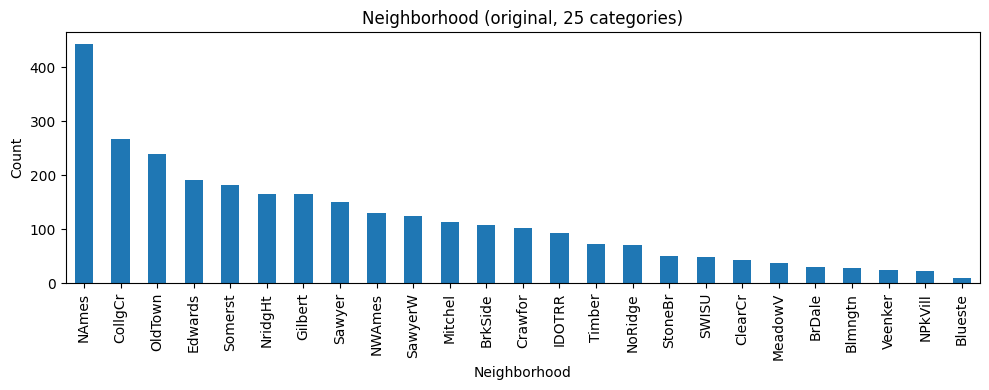

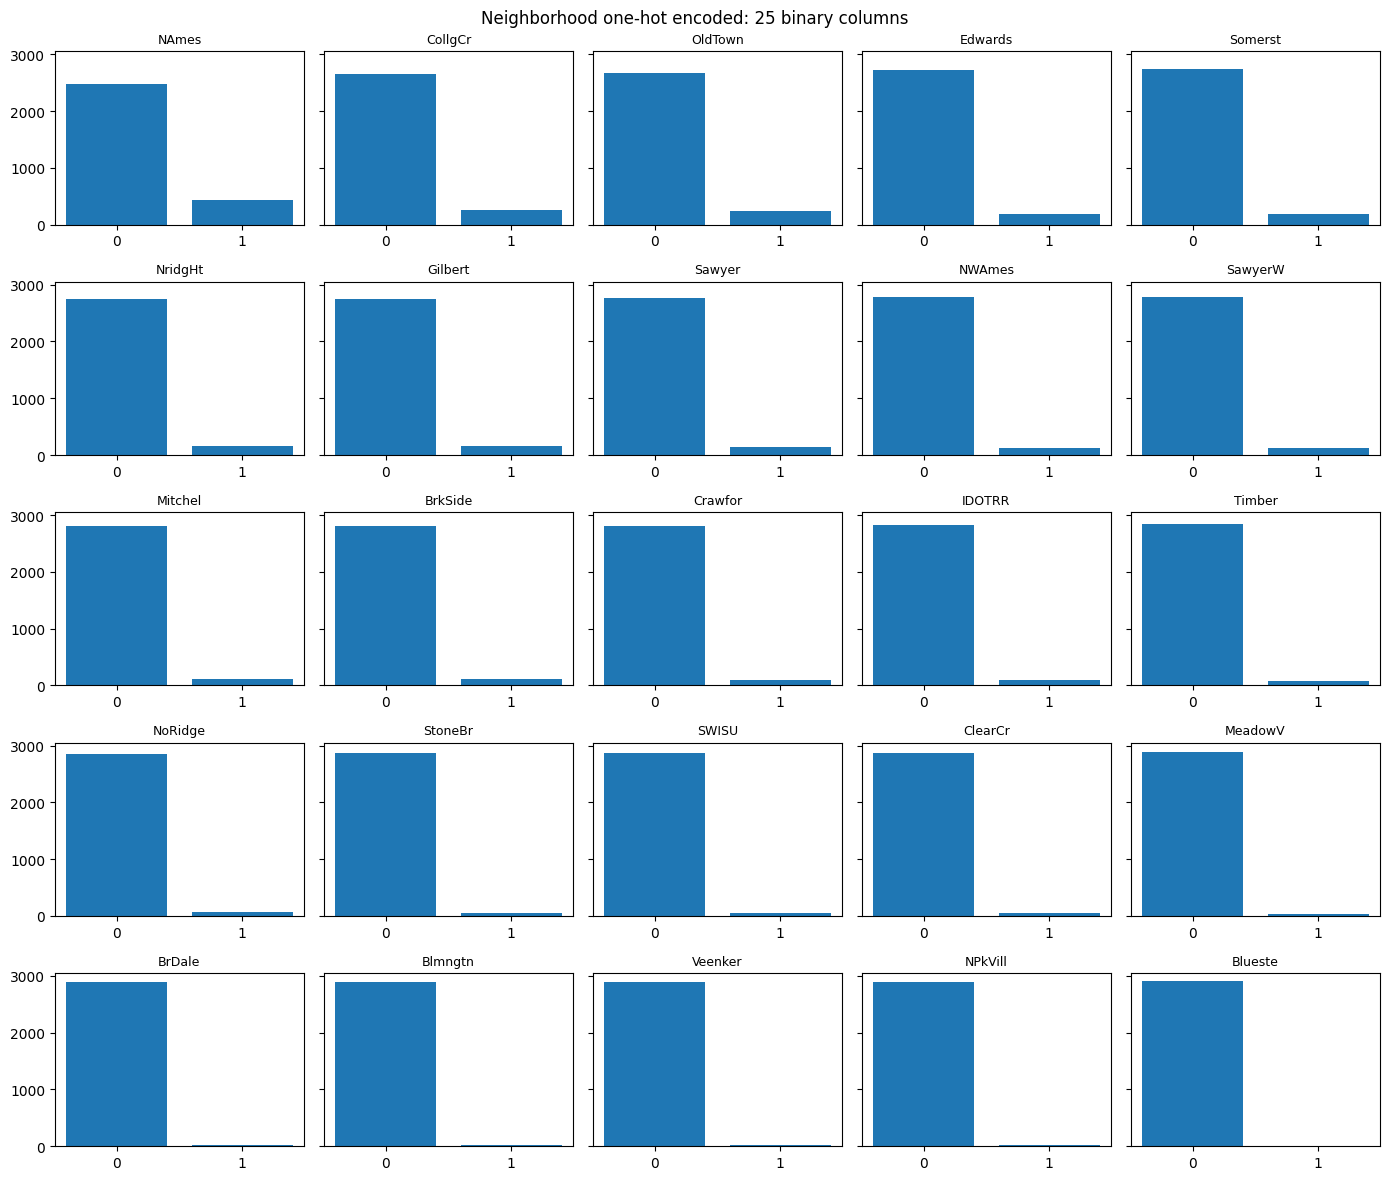

In [17]:
import matplotlib.pyplot as plt

feature = "Neighborhood"

counts = combined_df[feature].value_counts()
counts.plot(kind="bar", figsize=(10, 4))
plt.title(f"{feature} (original, {counts.size} categories)")
plt.ylabel("Count"); plt.tight_layout(); plt.show()

ohe = pd.get_dummies(combined_df[feature], prefix=feature, dtype=int)
ohe = ohe[[f"{feature}_{c}" for c in counts.index]]

fig, axes = plt.subplots(5, 5, figsize=(14, 12), sharey=True)
for ax, col in zip(axes.ravel(), ohe.columns):
    vc = ohe[col].value_counts().reindex([0, 1], fill_value=0)
    ax.bar([0, 1], vc.values)
    ax.set_xticks([0, 1]); ax.set_title(col.replace(f"{feature}_", ""), fontsize=9)
fig.suptitle(f"{feature} one-hot encoded: {ohe.shape[1]} binary columns")
plt.tight_layout(); plt.show()

In [18]:
combined_df = pd.get_dummies(combined_df, dtype=int)
print(combined_df.shape)

(2917, 273)


In [19]:
X_train = combined_df.iloc[:n_train]
X_test = combined_df.iloc[n_train:]

In [20]:
print(X_train.shape, X_test.shape)
print(X_train.isna().sum().sum())
print(len(X_train) == len(y_train_log))

(1458, 273) (1459, 273)
0
True


5. Using ordinary least squares (OLS), try to predict house prices on this dataset. Choose the features
(or combinations of features) you would like to use or ignore, provided you justify your choice.
Evaluate your predictions on the training set using the MSE and the $R^2$ score. For this question,
you need to implement OLS in 2 ways: 1) using the scikit-learn package, and 2) using autograd
from pytorch.

**Important**: you should not use high-level abstractions such as nn.Sequential or the built-in
linear layers. Instead, implement the solution from scratch using tensors and the code provided
in the code companion as a starting point.

In [21]:
# Marginal relationship of every column with log price (train rows only)
corr = X_train.corrwith(y_train_log).sort_values(key=abs, ascending=False)
print(corr.head(30))

top = corr.head(30).index
c = X_train[top].corr().abs()
pairs = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack()
print(pairs[pairs > 0.7].sort_values(ascending=False))

OverallQual          0.821405
TotalSF              0.817818
GrLivArea            0.737431
ExterQual            0.682226
GarageCars           0.681033
TotalBath            0.676678
KitchenQual          0.669990
GarageArea           0.656129
TotalBsmtSF          0.647563
BsmtQual             0.616897
1stFlrSF             0.615408
GarageFinish         0.605602
FullBath             0.595899
HouseAge            -0.587767
YearBuilt            0.587043
GarageYrBlt          0.569133
RemodAge            -0.568529
YearRemodAdd         0.565992
FireplaceQu          0.546791
TotRmsAbvGrd         0.537702
Foundation_PConc     0.531194
Fireplaces           0.491998
HeatingQC            0.473938
OpenPorchSF          0.460623
GarageType_Attchd    0.416377
MasVnrArea           0.413996
LotArea              0.402820
MSSubClass_60        0.402376
TotalPorchSF         0.399695
GarageType_Detchd   -0.388681
dtype: float64
HouseAge           YearBuilt            0.999034
RemodAge           YearRemodAdd     

/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [22]:
full_feats = list(X_train.columns)
weak_feats = ["MoSold_2", "MoSold_3", "MoSold_4", "MoSold_5", "MoSold_6",
              "YrSold", "LotFrontage", "MiscVal", "PoolArea", "3SsnPorch", "LowQualFinSF", "Street_Pave"]

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

curated_feats = ["OverallQual", "TotalSF", "GarageCars", "TotalBath", "KitchenQual", "BsmtQual",
                 "GarageFinish", "HouseAge", "RemodAge", "FireplaceQu", "Foundation_PConc",
                 "HeatingQC", "GarageType_Attchd", "MasVnrArea", "LotArea", "MSSubClass_60",
                 "TotalPorchSF"]

X = X_train[curated_feats]

ols = LinearRegression()
ols.fit(X, y_train_log)
pred_sk = ols.predict(X)

print("sklearn  MSE:", mean_squared_error(y_train_log, pred_sk))
print("sklearn  R2: ", r2_score(y_train_log, pred_sk))
print("Coefficients:", ols.coef_)
print("Intercept:   ", ols.intercept_)

sklearn  MSE: 0.018660491340430713
sklearn  R2:  0.8831241250192589
Coefficients: [ 0.10967532  0.11768708  0.03383345  0.04410535  0.03096897 -0.00591225
  0.01068732 -0.03602826 -0.03004079  0.02847019 -0.00726434  0.01702067
 -0.00270614  0.00300759  0.05503475  0.00050737  0.0179226 ]
Intercept:    12.028738369190437


/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [24]:
import torch
from torch.nn.functional import mse_loss

def f(X, theta):
    return torch.matmul(X, theta)

X_ones = X_train[curated_feats].copy()
X_ones["one"] = 1
X_t = torch.tensor(X_ones.to_numpy(), dtype=torch.float64)
y_t = torch.tensor(y_train_log.to_numpy(), dtype=torch.float64)

threshold = 1e-5
step_size = 0.05
max_iter = 50000

theta = torch.zeros(X_t.shape[1], dtype=torch.float64, requires_grad=True)
theta_prev = torch.ones(X_t.shape[1], dtype=torch.float64)
iter = 0

while torch.linalg.norm(theta - theta_prev) > threshold and iter < max_iter:
    theta_prev = theta.detach().clone()
    prediction = f(X_t, theta)
    loss = mse_loss(prediction, y_t)
    loss.backward()
    with torch.no_grad():
        theta = theta_prev - step_size * theta.grad
        theta = theta.requires_grad_()
    iter += 1
    if iter % 1000 == 0:
        print('Iteration %d. MSE: %.6f' % (iter, loss))

print("stopped after", iter, "iterations")
pred_torch = f(X_t, theta).detach().numpy()
print("torch  MSE:", mean_squared_error(y_train_log, pred_torch))
print("torch  R2: ", r2_score(y_train_log, pred_torch))

Iteration 1000. MSE: 0.018663
stopped after 1212 iterations
torch  MSE: 0.018660631301726124
torch  R2:  0.8831232484025306


/var/folders/1j/gpm6pvsn3jd2mhy8qyw5wddm0000gn/T/ipykernel_54035/3861157533.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('Iteration %d. MSE: %.6f' % (iter, loss))


6. Compare and discuss the two results that you obtained in Q5. In addition, identify situations where applying gradient descent is more desirable in the context of linear regression.

The two are very similar in their outputs. For MSE, I got 0.018660 for sklearn and 0.018661 for PyTorch, and for $R^2$ I got 0.8831 for both. That makes sense, since they're minimizing the same loss and it only has one minimum, so it doesn't matter how to get there. sklearn solves the least-squares problem directly in one shot, while PyTorch took 1212 gradient steps to walk down to it. The tiny coefficient gap is because gradient descent stops when it's barely moving, not when it's exactly at the bottom, so in flat directions it quits a little early. Gradient descent is the better choice when the data is too big to solve directly (a gradient step is cheap and can work on one batch at a time), when the model or loss isn't plain linear regression (logistic regression, neural nets are such that no closed form exists, but the same loop still works), or when you want to add something like L1 regularization that also has no closed form.

7. Train your model using all of the training data (all data points, but not necessarily all the features), and generate the predictions on the test set. Submit these test set predictions to Kaggle, as specified in the "Evaluation" > "Submission File Format" section.

Please submit a screenshot that highlights your position on Kaggle.

In [25]:
feats = curated_feats

ols = LinearRegression().fit(X_train[feats], y_train_log)
pred_test = np.expm1(ols.predict(X_test[feats]))

print(len(pred_test), pred_test.min(), pred_test.max())

submission = pd.DataFrame({"Id": test_ids, "SalePrice": pred_test})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)
print(list(submission.columns))

1459 50396.45895177358 727245.0596150883
     Id      SalePrice
0  1461  111099.984669
1  1462  157103.446293
2  1463  175531.771572
3  1464  203864.032062
4  1465  192120.030799
(1459, 2)
['Id', 'SalePrice']


/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


![Screenshot 2026-09-15 at 12.22.45 PM.png](<attachment:Screenshot 2026-09-15 at 12.22.45 PM.png>)
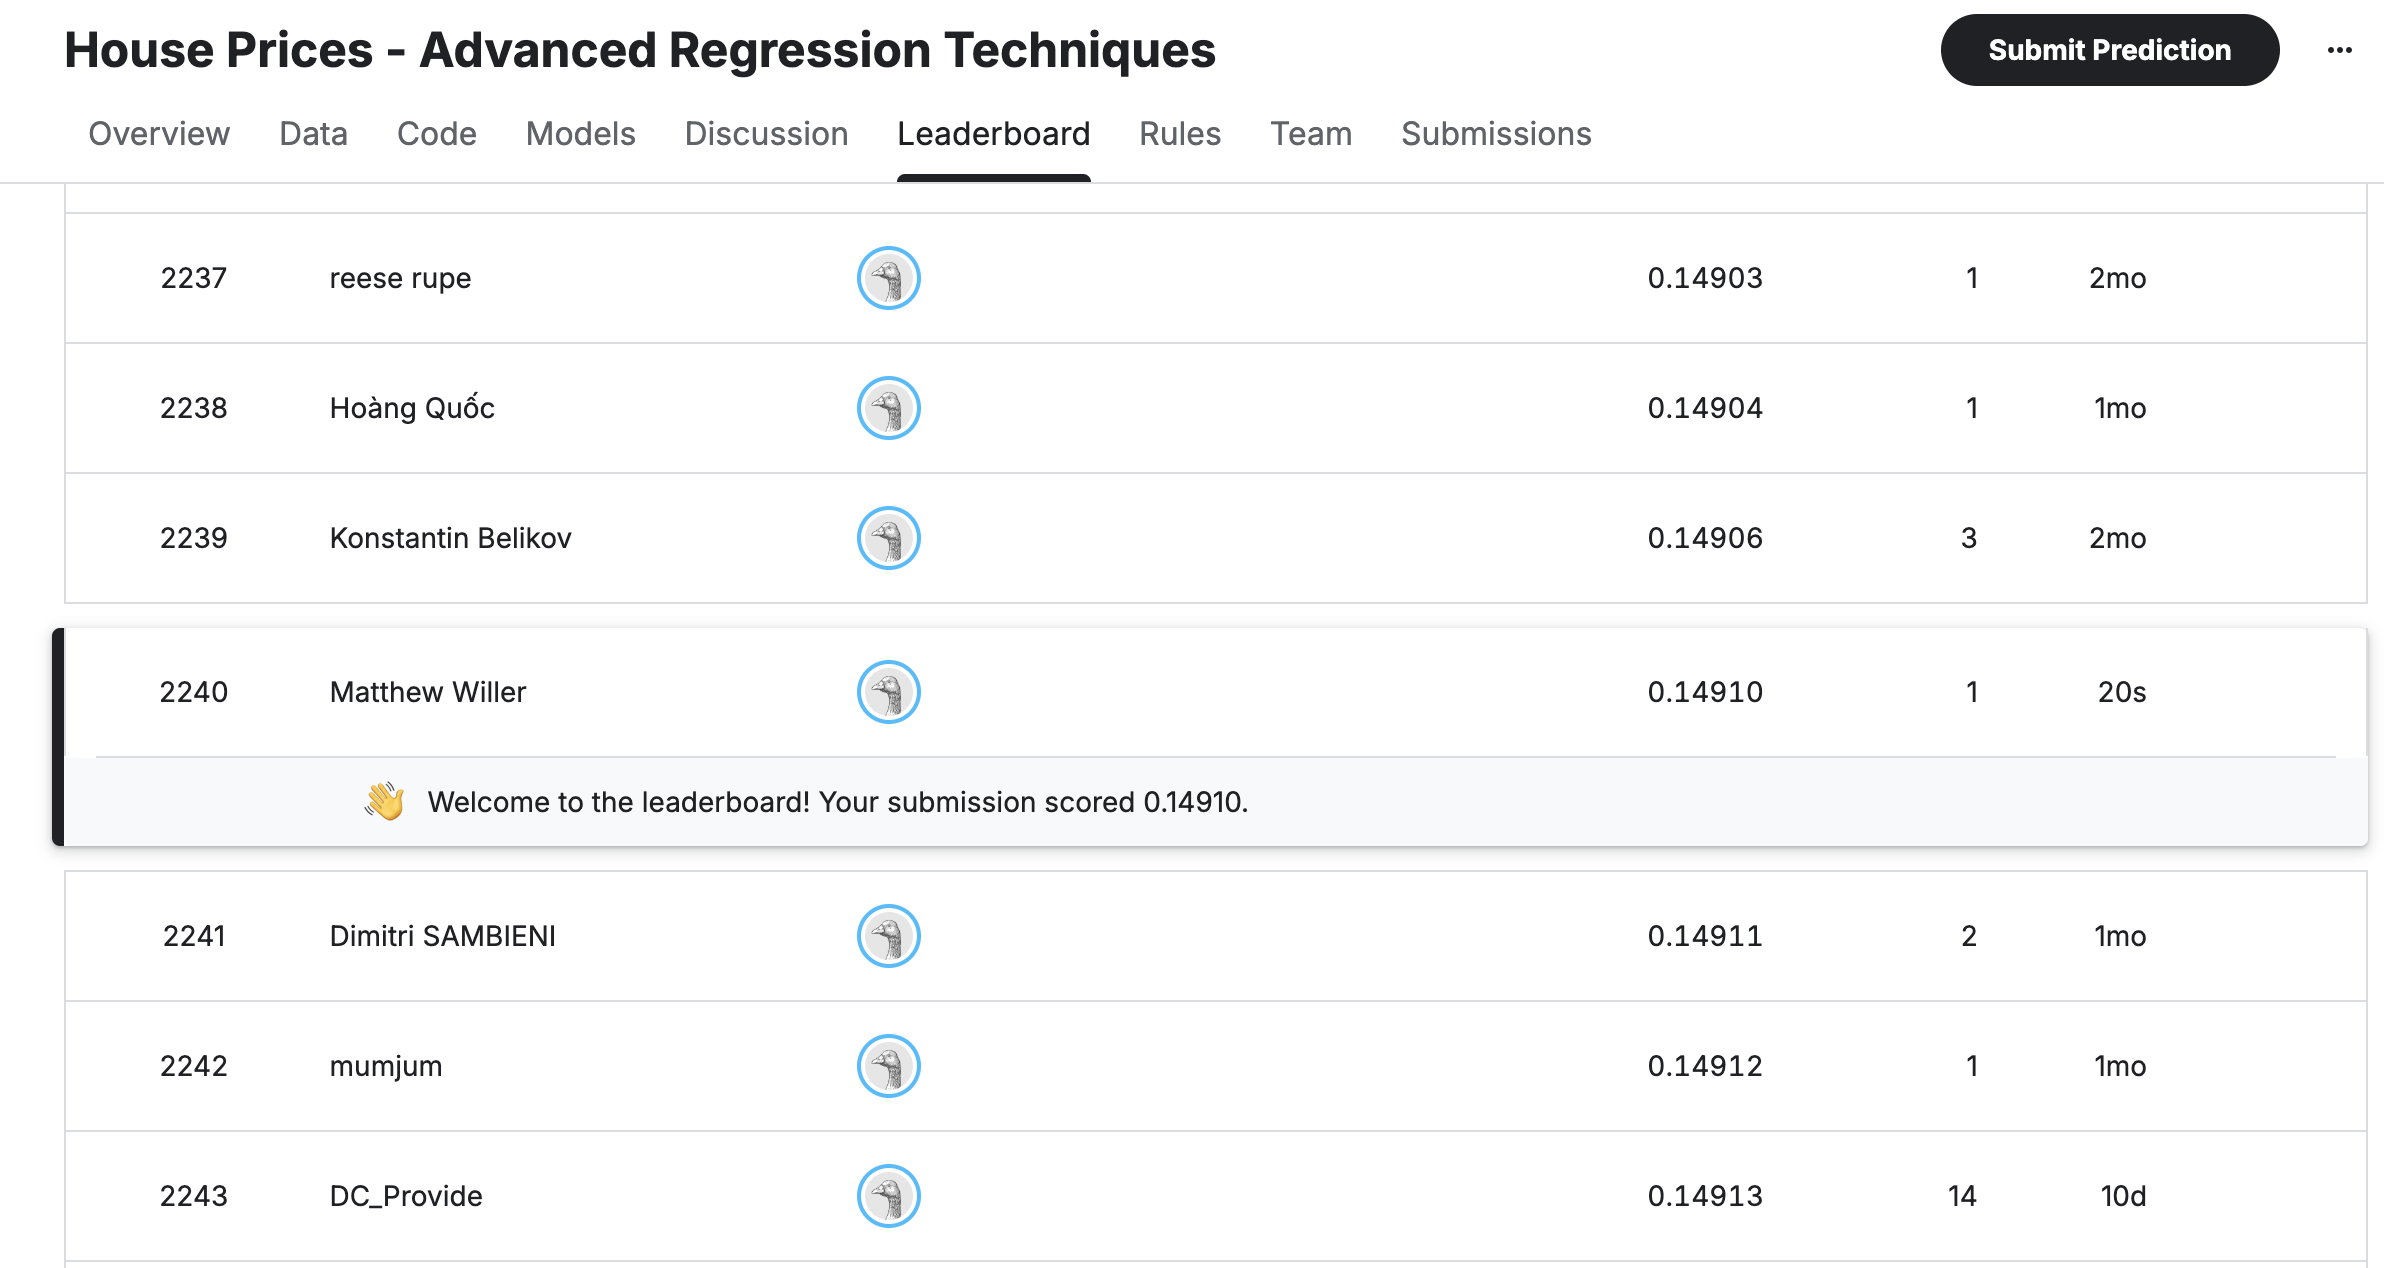

8. Select one model with poor performance and explain in words why the selected features are not predictive.

In [26]:
ols_weak = LinearRegression().fit(X_train[weak_feats], y_train_log)
pred_weak = ols_weak.predict(X_train[weak_feats])
print("weak  MSE:", mean_squared_error(y_train_log, pred_weak))
print("weak  R2: ", r2_score(y_train_log, pred_weak))
print("correlations with log price:\n", X_train[weak_feats].corrwith(y_train_log).round(3))

weak  MSE: 0.13513035516575964
weak  R2:  0.15364080139532177
correlations with log price:
 MoSold_2        0.011
MoSold_3        0.004
MoSold_4       -0.043
MoSold_5       -0.040
MoSold_6       -0.005
YrSold         -0.037
LotFrontage     0.368
MiscVal        -0.067
PoolArea        0.074
3SsnPorch       0.055
LowQualFinSF   -0.055
Street_Pave     0.057
dtype: float64


/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/matt/Desktop/AML/HW1/Part_II/house-prices-advanced-regression-techniques/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


The weak model uses month sold, year sold, lot frontage, and the rare features (MiscVal, PoolArea, 3SsnPorch, LowQualFinSF). It gets an MSE of 0.13513 and $R^2$ of 0.15364, compared to 0.01866 and 0.88312 for the curated feature set, so it's barely better than guessing the average price. The features aren't predictive for a few different reasons. Month and year of sale have nothing to do with what a house is worth. It makes sense that a house doesn't get more expensive because it closed in June, and 2006–2010 is too short a window for the market to move much. Lot frontage is only weakly related to price because a wide lot doesn't say anything about the size or quality of the house on it. And the rare features are almost all zeros. Fewer than a handful of houses have a pool or a three season porch, so for the vast majority of rows the column is 0 and gives the model nothing to work with. Even when it's nonzero, a pool is a small add-on relative to the size and quality of the house itself. Basically none of these columns describe how big or how nice the house is, which is what actually sets the price.

## Use of AI for this problem
For Part II, I used AI by providing the data_description.txt, test.csv, and train.csv to help determine steps for data pre-processing. Specifically, AI was used for handling skew in the dataset. Then for the OLS questions, I used the code companions and looked up sklearn and torch functions on the internet.